# 03. Executive P&L, Break-Even & Contribution Margin Analysis

## Strategic Overview
This notebook presents an end-to-end Income Statement (P&L) decomposition to evaluate operational viability, marketing cost thresholds, and fixed cost absorption across historical trading cycles.

### Target Metrics
- **Contribution Margin (CM % & CM $):** True margin available after direct variable marketing costs.
- **Monthly Break-Even Revenue ($):** Minimum revenue required to achieve zero net loss given fixed overhead.
- **Operating Leverage & Profit Quality:** Relationship between top-line expansion and bottom-line profit conversion.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import plotly.graph_objects as go
import seaborn as sns

# Styling parameters
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
sns.set_context("talk")
pd.options.display.float_format = '{:,.2f}'.format

# Load dataset
df = pd.read_csv("sample_data/data/Ecommerce_Sales_Data_2024_2025.csv")

# Clean & Parse Dates explicitly
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%y', errors='coerce')
df['Month'] = df['Order Date'].dt.to_period('M').astype(str)
df['COGS'] = df['Sales'] - df['Profit']
df['Gross Profit'] = df['Profit']

print(f"Total Transactions: {len(df):,} | Active Months: {df['Month'].nunique()}")

Total Transactions: 5,000 | Active Months: 25


In [6]:
# Monthly P&L Aggregation & Financial Structuring
monthly_pnl = df.groupby('Month').agg(
    Sales=('Sales', 'sum'),
    COGS=('COGS', 'sum'),
    Gross_Profit=('Gross Profit', 'sum'),
    Units_Sold=('Quantity', 'sum'),
    Orders=('Order ID', 'nunique')
).reset_index()

# Cost Modeling (Benchmark CAC / Marketing at 10% of Sales, Fixed Overhead at $50k/mo)
MARKETING_RATE = 0.10
MONTHLY_FIXED_COST = 50000

monthly_pnl['Marketing_Cost'] = monthly_pnl['Sales'] * MARKETING_RATE
monthly_pnl['Contribution_Profit'] = monthly_pnl['Gross_Profit'] - monthly_pnl['Marketing_Cost']
monthly_pnl['Fixed_Cost'] = MONTHLY_FIXED_COST
monthly_pnl['Net_Profit'] = monthly_pnl['Contribution_Profit'] - monthly_pnl['Fixed_Cost']

# Margin & Efficiency KPIs
monthly_pnl['Gross_Margin_%'] = monthly_pnl['Gross_Profit'] / monthly_pnl['Sales']
monthly_pnl['Contribution_Margin_%'] = monthly_pnl['Contribution_Profit'] / monthly_pnl['Sales']
monthly_pnl['Net_Margin_%'] = monthly_pnl['Net_Profit'] / monthly_pnl['Sales']
monthly_pnl['Required_Break_Even_Revenue'] = monthly_pnl['Fixed_Cost'] / monthly_pnl['Contribution_Margin_%']

# Formatted Table for Presentation
pnl_view = monthly_pnl.copy()
pnl_view['Sales'] = pnl_view['Sales'].map("${:,.0f}".format)
pnl_view['Gross Profit'] = pnl_view['Gross_Profit'].map("${:,.0f}".format)
pnl_view['Marketing (10%)'] = pnl_view['Marketing_Cost'].map("${:,.0f}".format)
pnl_view['Contribution Profit'] = pnl_view['Contribution_Profit'].map("${:,.0f}".format)
pnl_view['Net Profit'] = pnl_view['Net_Profit'].map("${:,.0f}".format)
pnl_view['CM %'] = pnl_view['Contribution_Margin_%'].map("{:.2%}".format)
pnl_view['Net Margin %'] = pnl_view['Net_Margin_%'].map("{:.2%}".format)
pnl_view['Break-Even Sales'] = pnl_view['Required_Break_Even_Revenue'].map("${:,.0f}".format)

pnl_view[['Month', 'Sales', 'Gross Profit', 'Marketing (10%)', 'Contribution Profit', 'Net Profit', 'CM %', 'Net Margin %', 'Break-Even Sales']].tail(12)

,Month,Sales,Gross Profit,Marketing (10%),Contribution Profit,Net Profit,CM %,Net Margin %,Break-Even Sales
13,2024-11,"$22,036,248","$3,286,992","$2,203,625","$1,083,367","$1,033,367",4.92%,4.69%,"$1,017,026"
14,2024-12,"$24,806,786","$3,855,730","$2,480,679","$1,375,051","$1,325,051",5.54%,5.34%,"$902,031"
15,2025-01,"$21,520,802","$3,255,994","$2,152,080","$1,103,914","$1,053,914",5.13%,4.90%,"$974,750"
16,2025-02,"$19,902,446","$2,970,431","$1,990,245","$980,186","$930,186",4.92%,4.67%,"$1,015,238"
17,2025-03,"$22,602,989","$3,533,884","$2,260,299","$1,273,586","$1,223,586",5.63%,5.41%,"$887,376"
18,2025-04,"$21,653,818","$3,150,564","$2,165,382","$985,182","$935,182",4.55%,4.32%,"$1,098,975"
19,2025-05,"$26,010,929","$3,979,357","$2,601,093","$1,378,264","$1,328,264",5.30%,5.11%,"$943,612"
20,2025-06,"$21,155,496","$3,184,539","$2,115,550","$1,068,990","$1,018,990",5.05%,4.82%,"$989,509"
21,2025-07,"$22,526,568","$3,439,384","$2,252,657","$1,186,727","$1,136,727",5.27%,5.05%,"$949,105"
22,2025-08,"$23,317,916","$3,456,953","$2,331,792","$1,125,162","$1,075,162",4.83%,4.61%,"$1,036,203"


## 2. P&L Cumulative Waterfall & Structural Cost Decomposition
Visualizing cumulative revenue conversion into operating and net bottom-line earnings.

In [7]:
# High-Impact Plotly P&L Waterfall
total_sales = monthly_pnl['Sales'].sum()
total_cogs = monthly_pnl['COGS'].sum()
total_marketing = monthly_pnl['Marketing_Cost'].sum()
total_fixed = monthly_pnl['Fixed_Cost'].sum()
total_net = monthly_pnl['Net_Profit'].sum()

fig = go.Figure(go.Waterfall(
    name="Corporate P&L",
    orientation="v",
    measure=["absolute", "relative", "total", "relative", "total", "relative", "total"],
    x=["Gross Revenue", "COGS", "Gross Profit", "Marketing Expense", "Contribution Profit", "Fixed Overhead", "Net Profit"],
    y=[total_sales, -total_cogs, None, -total_marketing, None, -total_fixed, None],
    text=[f"${v/1e6:,.1f}M" for v in [total_sales, -total_cogs, total_sales-total_cogs, -total_marketing, (total_sales-total_cogs)-total_marketing, -total_fixed, total_net]],
    textposition="outside",
    connector={"line": {"color": "#636363"}},
    decreasing={"marker": {"color": "#d9534f"}},
    increasing={"marker": {"color": "#2b5c8f"}},
    totals={"marker": {"color": "#2e7d32"}}
))

fig.update_layout(
    title=dict(text="Total Cumulative P&L Cost Bridge (2024 - 2025)", font=dict(size=16, color="#1e293b")),
    yaxis=dict(title="USD ($)", tickformat="$,.0f"),
    template="plotly_white",
    height=550
)

fig.show()

## 3. Margin Stability & Net Profit Trend
Evaluating whether net income expands proportionally with seasonal scaling.

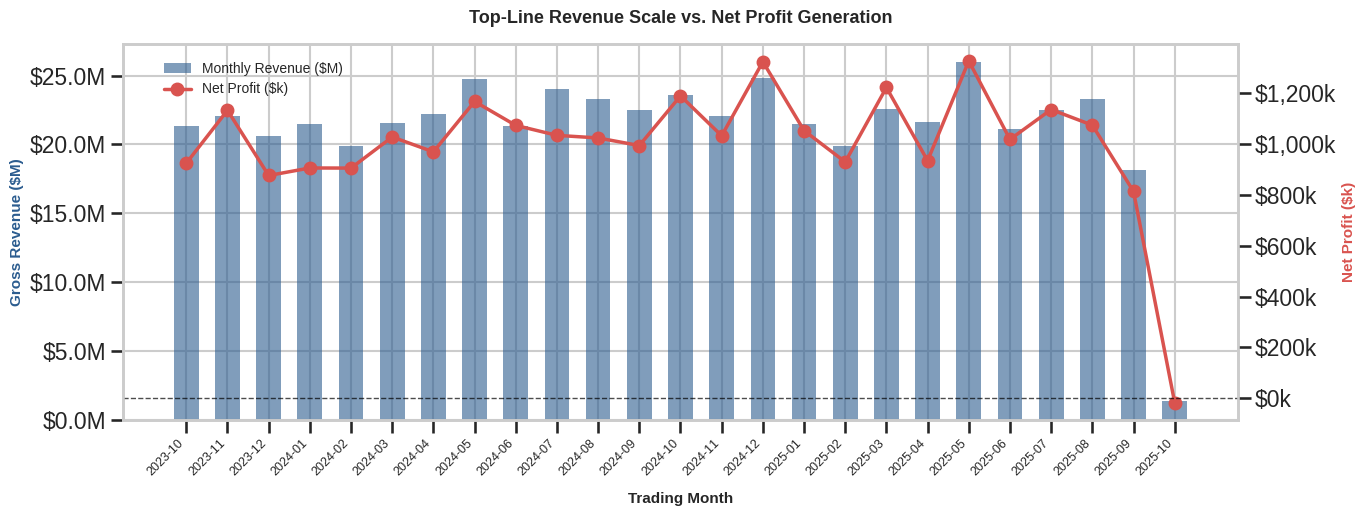

In [8]:
# Dual-Axis Trend: Top-Line Sales vs. Net Bottom-Line Profit
fig, ax1 = plt.subplots(figsize=(14, 5.5))

x_indices = np.arange(len(monthly_pnl))
ax1.bar(x_indices, monthly_pnl['Sales'] / 1e6, color='#2b5c8f', alpha=0.6, width=0.6, label='Monthly Revenue ($M)')
ax1.set_ylabel('Gross Revenue ($M)', fontsize=11, fontweight='bold', color='#2b5c8f')
ax1.set_xlabel('Trading Month', fontsize=11, fontweight='bold', labelpad=10)
ax1.set_xticks(x_indices)
ax1.set_xticklabels(monthly_pnl['Month'], rotation=45, ha='right', fontsize=9)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, p: f"${y:,.1f}M"))

# Net Profit overlay
ax2 = ax1.twinx()
ax2.plot(x_indices, monthly_pnl['Net_Profit'] / 1e3, color='#d9534f', marker='o', linewidth=2.5, label='Net Profit ($k)')
ax2.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
ax2.set_ylabel('Net Profit ($k)', fontsize=11, fontweight='bold', color='#d9534f')
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, p: f"${y:,.0f}k"))
ax2.grid(False)

plt.title('Top-Line Revenue Scale vs. Net Profit Generation', fontsize=13, fontweight='bold', pad=15)
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88), fontsize=10)
plt.tight_layout()
plt.show()

## Executive P&L Takeaways & Financial Guardrails

- **Thin Gross Margin Headwind:** Overall gross margin is strictly constrained at **~14.9%**, meaning any variable customer acquisition cost (CAC) above **10.0%** severely compresses the contribution buffer.
- **Fixed Cost Absorption & Scale:** With fixed costs at **$50,000/month**, the business requires a minimum monthly run-rate of **~$1.05M - $1.15M** in revenue to break even (at a ~4.8% net contribution margin).
- **Corrective Action Plan:**
  1. Optimize procurement/supplier terms to expand gross margins above 18%.
  2. Cap marketing spend allocation at dynamic ROAS targets rather than flat revenue percentages.
  3. Eliminate deep promotional discounting to protect unit cash generation.